# SRQ1 — Architecture Evaluation

Trains all 8 attention-augmented ResNet18 architectures under 5-fold stratified CV using the optimal hyperparameters from the grid search and the winning head type from the ablation study. Weights are saved per architecture per fold for use in downstream experiments.

**Architectures (8 total):**
- `base` — plain ResNet18 baseline
- `cbam_end` — single CBAM after avgpool
- `cbam_block_pre` — CBAM inside each block, pre-shortcut
- `cbam_block_post` — CBAM inside each block, post-shortcut
- `se_end` — single SE block after avgpool
- `se_block_pre` — SE inside each block, pre-shortcut
- `cbam_isolated_end` — CBAMIsolated (SE channel + CBAM spatial) after avgpool
- `cbam_isolated_block_pre` — CBAMIsolated inside each block, pre-shortcut

**Protocol:**
- Head type and hyperparameters loaded automatically from prior experiment outputs
- 5-fold stratified CV; 8 architectures × 5 folds = 40 runs
- Weights saved to `arch-eval-results/weights/<architecture>/fold_<n>.pt` after each fold
- Results saved fold-by-fold to `arch-eval-results/arch_eval_results.csv` — safe to interrupt and resume
- **Selection criterion:** highest mean val F1. Ties: highest mean val acc, then lowest mean val loss.
- **Section 9:** Final held-out test set evaluation — run once only after all CV decisions are made.

## 1 · Paths & Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[1]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "arch-eval-results"
WEIGHTS_DIR   = RESULTS_DIR / "weights"
CURVES_DIR   = RESULTS_DIR / "training-curves"
PLOTS_DIR    = RESULTS_DIR / "plots"

GRID_SEARCH_RESULTS_DIR = PROJECT_ROOT / "data" / "experiments" / "grid-search-results"
HEAD_ABLATION_RESULTS_DIR = PROJECT_ROOT / "data" / "experiments" / "head-ablation-results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
CURVES_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Weights dir  : {WEIGHTS_DIR}")
print(f"Curves dir   : {CURVES_DIR}")
print(f"Plots dir    : {PLOTS_DIR}")

Project root : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Results dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results
Weights dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\weights
Curves dir   : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\training-curves
Plots dir    : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\plots


In [2]:
import csv
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import f1_score

import src.scripts.data    as data
import src.scripts.models  as models
import src.scripts.trainer as trainer
import src.scripts.utils     as utils
import src.scripts.evaluator as evaluator

utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## 2 · Data — Outer Split (Identical to All Other Experiments)

Fixed seed 42 outer split. Architecture evaluation operates entirely within `X_trainval`; the held-out test set remains untouched until final evaluation.

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nArchitecture evaluation operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used until Section 9 (final evaluation).")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

Architecture evaluation operates on 1321 train+val samples.
Held-out test set is NOT used until Section 9 (final evaluation).


## 3 · Configuration

Hyperparameters are loaded from `grid-search-results/optimal_config.csv` (grid search output). The winning head type is loaded from `head-ablation-results/optimal_head.csv` (ablation output). Both files must exist before running this notebook.

In [4]:
# ── Load optimal hyperparameters from grid search ────────────────────────
OPTIMAL_CONFIG_FILE = GRID_SEARCH_RESULTS_DIR / "optimal_config.csv"
if not OPTIMAL_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"optimal_config.csv not found at {OPTIMAL_CONFIG_FILE}\n"
        "Run the grid search notebook (Section 5) first."
    )

optimal = pd.read_csv(OPTIMAL_CONFIG_FILE).iloc[0]
LR_PHASE1         = float(optimal["lr_phase1"])
WD_PHASE1         = float(optimal["wd_phase1"])
BEST_LR_PHASE2    = float(optimal["lr_phase2"])
BEST_WEIGHT_DECAY = float(optimal["weight_decay"])

print(f"Loaded from : {OPTIMAL_CONFIG_FILE.name}")
print(f"  lr_phase1    = {LR_PHASE1:.0e}")
print(f"  wd_phase1    = {WD_PHASE1}")
print(f"  lr_phase2    = {BEST_LR_PHASE2:.0e}")
print(f"  weight_decay = {BEST_WEIGHT_DECAY:.0e}")

# ── Load winning head from ablation optimal_head.csv ─────────────────────────
OPTIMAL_HEAD_FILE = HEAD_ABLATION_RESULTS_DIR / "optimal_head.csv"
if not OPTIMAL_HEAD_FILE.exists():
    raise FileNotFoundError(
        f"optimal_head.csv not found at {OPTIMAL_HEAD_FILE}\n"
        "Run the head ablation notebook (Section 5 + save cell) first."
    )

optimal_head = pd.read_csv(OPTIMAL_HEAD_FILE).iloc[0]
WINNING_HEAD = optimal_head["head"]

print(f"Loaded from : {OPTIMAL_HEAD_FILE.name}")
print(f"  winning head = {WINNING_HEAD}")
print(f"  mean_val_f1  = {float(optimal_head['mean_val_f1']):.4f}")
print(f"  mean_val_acc = {float(optimal_head['mean_val_acc']):.4f}")

Loaded from : optimal_config.csv
  lr_phase1    = 1e-03
  wd_phase1    = 0.0
  lr_phase2    = 1e-04
  weight_decay = 1e-04
Loaded from : optimal_head.csv
  winning head = linear
  mean_val_f1  = 0.9174
  mean_val_acc = 0.9372


In [5]:
# ── Fixed training parameters ─────────────────────────────────────────────
N_SPLITS    = 5
BATCH_SIZE  = 32
P1_EPOCHS   = 20
P2_EPOCHS   = 15
P1_PATIENCE = 4
P2_PATIENCE = 3
SEED        = 42

# ── Architecture list — order determines run sequence ─────────────────────
ARCHITECTURES = [
    "base",
    "cbam_end",
    "cbam_block_pre",
    "cbam_block_post",
    "se_end",
    "se_block_pre",
    "cbam_isolated_end",
    "cbam_isolated_block_pre",
]

RESULTS_FILE = RESULTS_DIR / "arch_eval_results.csv"
CSV_FIELDNAMES = [
    "architecture", "head", "lr_phase1", "wd_phase1", "lr_phase2", "weight_decay",
    "fold", "val_acc", "val_loss", "val_f1",
    "p1_epochs_run", "p2_epochs_run",
    "weights_path", "timestamp", "error"
]

total_runs = len(ARCHITECTURES) * N_SPLITS
print(f"{len(ARCHITECTURES)} architectures * {N_SPLITS} folds = {total_runs} runs")
print(f"Head      : {WINNING_HEAD}")
print(f"lr_phase2 : {BEST_LR_PHASE2:.0e}  weight_decay : {BEST_WEIGHT_DECAY:.0e}")
print(f"Results   → {RESULTS_FILE}")
print(f"Weights   → {WEIGHTS_DIR}/<architecture>/fold_<n>.pt")

8 architectures * 5 folds = 40 runs
Head      : linear
lr_phase2 : 1e-04  weight_decay : 1e-04
Results   → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\arch_eval_results.csv
Weights   → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\weights/<architecture>/fold_<n>.pt


## 5 · Training Loop

Outer loop: architectures. Inner loop: folds. After each fold: weights saved to `weights/<arch>/fold_<n>.pt`, training curves saved to `training-curves/<arch>/phase1_fold<n>_curves.png` and `phase2_fold<n>_curves.png`. `show=False` keeps the notebook output clean during long runs. Expected duration: ~20 min/run × 40 runs ≈ 13 hours on CPU.

In [6]:
completed_runs = utils.load_completed_runs(RESULTS_FILE, [("architecture", str), ("fold", int)])
run_number     = len(completed_runs)

for arch in ARCHITECTURES:
    for fold_idx in range(N_SPLITS):

        run_key = (arch, fold_idx)

        if run_key in completed_runs:
            print(f"SKIP  arch={arch}  fold={fold_idx+1}/{N_SPLITS}")
            continue

        utils.set_seed(SEED)
        run_number += 1
        print(f"\n{'='*65}")
        print(f"  Run {run_number}/{total_runs}  |  arch={arch}  fold={fold_idx+1}/{N_SPLITS}")
        print(f"{'='*65}")

        try:
            train_loader, val_loader = data.get_fold_loaders(
                X_trainval, y_trainval,
                fold_idx=fold_idx,
                train_transform=train_transform,
                test_transform=test_transform,
                n_splits=N_SPLITS,
                batch_size=BATCH_SIZE,
                SEED=SEED
            )

            model = models.get_model(architecture=arch, head=WINNING_HEAD)

            run_configs = {
                "phase1": {
                    "num_epochs"  : P1_EPOCHS,
                    "lr"          : LR_PHASE1,
                    "parameters"  : "head_and_attention",
                    "optimiser"   : optim.AdamW,
                    "criterion"   : nn.BCEWithLogitsLoss(),
                    "weight_decay": WD_PHASE1,
                },
                "phase2": {
                    "num_epochs"  : P2_EPOCHS,
                    "lr"          : BEST_LR_PHASE2,
                    "parameters"  : "all",
                    "optimiser"   : optim.AdamW,
                    "criterion"   : nn.BCEWithLogitsLoss(),
                    "weight_decay": BEST_WEIGHT_DECAY,
                },
            }

            # Phase 1: head + attention warm-up
            losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
                model, train_loader, val_loader,
                config_name="phase1",
                train_configs=run_configs,
                early_stopping_patience=P1_PATIENCE
            )
            p1_epochs_run = len(val_accs_p1)

            utils.plot(
                losses_p1, accs_p1,
                config_name=f"phase1_fold{fold_idx}",
                val_losses=val_losses_p1, val_accuracies=val_accs_p1,
                model_name=arch,
                save_dir=str(CURVES_DIR),
                show=False
            )

            # Phase 2: full fine-tune
            losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
                model, train_loader, val_loader,
                config_name="phase2",
                train_configs=run_configs,
                early_stopping_patience=P2_PATIENCE
            )
            p2_epochs_run = len(val_accs_p2)

            utils.plot(
                losses_p2, accs_p2,
                config_name=f"phase2_fold{fold_idx}",
                val_losses=val_losses_p2, val_accuracies=val_accs_p2,
                model_name=arch,
                save_dir=str(CURVES_DIR),
                show=False
            )

            # F1 inference pass
            model.eval()
            all_preds, all_labels_list = [], []
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs   = imgs.to(next(model.parameters()).device)
                    logits = model(imgs).squeeze(1)
                    preds  = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
                    all_preds.extend(preds)
                    all_labels_list.extend(lbls.tolist())
            val_f1 = f1_score(all_labels_list, all_preds, average="binary", zero_division=0)

            # Save weights
            wpath = utils.weights_path_for(WEIGHTS_DIR, arch, fold_idx)
            utils.save_weights(model, wpath)

            result_row = {
                "architecture" : arch,
                "head"         : WINNING_HEAD,
                "lr_phase1"    : LR_PHASE1,
                "wd_phase1"    : WD_PHASE1,
                "lr_phase2"    : BEST_LR_PHASE2,
                "weight_decay" : BEST_WEIGHT_DECAY,
                "fold"         : fold_idx,
                "val_acc"      : round(float(val_accs_p2[-1]),  6),
                "val_loss"     : round(float(val_losses_p2[-1]), 6),
                "val_f1"       : round(float(val_f1), 6),
                "p1_epochs_run": p1_epochs_run,
                "p2_epochs_run": p2_epochs_run,
                "weights_path" : str(wpath),
                "timestamp"    : datetime.now().isoformat(timespec="seconds"),
                "error"        : "",
            }
            utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, result_row)
            completed_runs.add(run_key)

            print(f"  val_acc={val_accs_p2[-1]:.4f}  "
                  f"val_f1={val_f1:.4f}  "
                  f"val_loss={val_losses_p2[-1]:.4f}  "
                  f"(p1={p1_epochs_run}ep  p2={p2_epochs_run}ep)")
            print(f"  Weights → {wpath}")
            print(f"  Curves  → {CURVES_DIR}/{arch}/")

        except Exception as e:
            error_msg = f"{type(e).__name__}: {str(e)}"
            print(f"ERROR -- {error_msg}")
            traceback.print_exc()
            error_row = {
                "architecture" : arch,
                "head"         : WINNING_HEAD,
                "lr_phase1"    : LR_PHASE1,    "wd_phase1"    : WD_PHASE1,
                "lr_phase2"    : BEST_LR_PHASE2, "weight_decay": BEST_WEIGHT_DECAY,
                "fold"         : fold_idx,
                "val_acc"      : "", "val_loss": "", "val_f1": "",
                "p1_epochs_run": "", "p2_epochs_run": "",
                "weights_path" : "",
                "timestamp"    : datetime.now().isoformat(timespec="seconds"),
                "error"        : error_msg,
            }
            utils.append_result(RESULTS_FILE, CSV_FIELDNAMES, error_row)

print(f"\n{'='*65}")
print("ARCHITECTURE EVALUATION COMPLETE")
print(f"Results  → {RESULTS_FILE}")
print(f"Weights  → {WEIGHTS_DIR}")
print(f"Curves   → {CURVES_DIR}")

SKIP  arch=base  fold=1/5
SKIP  arch=base  fold=2/5
SKIP  arch=base  fold=3/5
SKIP  arch=base  fold=4/5
SKIP  arch=base  fold=5/5
SKIP  arch=cbam_end  fold=1/5
SKIP  arch=cbam_end  fold=2/5
SKIP  arch=cbam_end  fold=3/5
SKIP  arch=cbam_end  fold=4/5
SKIP  arch=cbam_end  fold=5/5
SKIP  arch=cbam_block_pre  fold=1/5
SKIP  arch=cbam_block_pre  fold=2/5
SKIP  arch=cbam_block_pre  fold=3/5
SKIP  arch=cbam_block_pre  fold=4/5
SKIP  arch=cbam_block_pre  fold=5/5
SKIP  arch=cbam_block_post  fold=1/5
SKIP  arch=cbam_block_post  fold=2/5
SKIP  arch=cbam_block_post  fold=3/5
SKIP  arch=cbam_block_post  fold=4/5
SKIP  arch=cbam_block_post  fold=5/5
SKIP  arch=se_end  fold=1/5
SKIP  arch=se_end  fold=2/5
SKIP  arch=se_end  fold=3/5
SKIP  arch=se_end  fold=4/5
SKIP  arch=se_end  fold=5/5
SKIP  arch=se_block_pre  fold=1/5
SKIP  arch=se_block_pre  fold=2/5
SKIP  arch=se_block_pre  fold=3/5
SKIP  arch=se_block_pre  fold=4/5
SKIP  arch=se_block_pre  fold=5/5
SKIP  arch=cbam_isolated_end  fold=1/5
SKIP  

## 6 · Results Analysis

Run after training completes (or at any point during it for partial results).

In [7]:
df_raw = pd.read_csv(RESULTS_FILE)
df_raw["error"] = df_raw["error"].fillna("")

df_ok   = df_raw[df_raw["error"] == ""].copy()
df_fail = df_raw[df_raw["error"] != ""].copy()

for col in ["val_f1", "val_acc", "val_loss"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_runs}")
print(f"Failed runs     : {len(df_fail)}")
if len(df_fail) > 0:
    print(df_fail[["architecture", "fold", "error"]].to_string(index=False))

Successful runs : 40 / 40
Failed runs     : 0


In [8]:
# Summary table — mean ± std across 5 folds per architecture
summary = (
    df_ok
    .groupby("architecture")
    .agg(
        mean_val_f1   = ("val_f1",        "mean"),
        std_val_f1    = ("val_f1",        "std"),
        mean_val_acc  = ("val_acc",       "mean"),
        std_val_acc   = ("val_acc",       "std"),
        mean_val_loss = ("val_loss",      "mean"),
        std_val_loss  = ("val_loss",      "std"),
        mean_p2_epochs= ("p2_epochs_run", "mean"),
        n_folds       = ("val_f1",        "count"),
    )
    .reset_index()
    .sort_values("mean_val_f1", ascending=False)
)

summary["val_f1_display"]  = summary.apply(lambda r: f"{r.mean_val_f1:.4f} ± {r.std_val_f1:.4f}", axis=1)
summary["val_acc_display"] = summary.apply(lambda r: f"{r.mean_val_acc:.4f} ± {r.std_val_acc:.4f}", axis=1)
summary["val_loss_display"]= summary.apply(lambda r: f"{r.mean_val_loss:.4f} ± {r.std_val_loss:.4f}", axis=1)

display_cols = ["architecture", "val_f1_display", "val_acc_display", "val_loss_display",
                "mean_p2_epochs", "n_folds"]

print("\nArchitecture evaluation summary (sorted by mean val F1):\n")
summary[display_cols]


Architecture evaluation summary (sorted by mean val F1):



,architecture,val_f1_display,val_acc_display,val_loss_display,mean_p2_epochs,n_folds
3,cbam_end,0.9254 ± 0.0222,0.9432 ± 0.0167,0.1739 ± 0.0431,10.2,5
0,base,0.9174 ± 0.0272,0.9372 ± 0.0195,0.1996 ± 0.0813,6.8,5
6,se_block_pre,0.9070 ± 0.0309,0.9289 ± 0.0249,0.2291 ± 0.0617,9.8,5
5,cbam_isolated_end,0.9051 ± 0.0333,0.9258 ± 0.0235,0.2540 ± 0.1021,7.0,5
7,se_end,0.9041 ± 0.0414,0.9228 ± 0.0414,0.2606 ± 0.1007,9.2,5
1,cbam_block_post,0.8991 ± 0.0297,0.9228 ± 0.0265,0.2675 ± 0.0649,9.0,5
4,cbam_isolated_block_pre,0.8917 ± 0.0331,0.9122 ± 0.0311,0.2788 ± 0.0773,8.0,5
2,cbam_block_pre,0.8635 ± 0.0571,0.8940 ± 0.0491,0.3992 ± 0.2672,6.4,5


In [9]:
# Winning architecture
best = summary.sort_values(
    ["mean_val_f1", "mean_val_acc", "mean_val_loss"],
    ascending=[False, False, True]
).iloc[0]

baseline = summary[summary["architecture"] == "base"].iloc[0]

print("\n" + "="*60)
print("  WINNING ARCHITECTURE")
print("="*60)
print(f"  Architecture  : {best['architecture']}")
print(f"  Mean val F1   : {best.mean_val_f1:.4f} ± {best.std_val_f1:.4f}")
print(f"  Mean val acc  : {best.mean_val_acc:.4f} ± {best.std_val_acc:.4f}")
print(f"  Mean val loss : {best.mean_val_loss:.4f} ± {best.std_val_loss:.4f}")
print("="*60)
print(f"\n  ΔF1 vs baseline  : {best.mean_val_f1 - baseline.mean_val_f1:+.4f}")
print(f"  ΔAcc vs baseline : {best.mean_val_acc  - baseline.mean_val_acc:+.4f}")

WINNING_ARCH = best["architecture"]
print(f"\nWINNING_ARCH = '{WINNING_ARCH}'")


  WINNING ARCHITECTURE
  Architecture  : cbam_end
  Mean val F1   : 0.9254 ± 0.0222
  Mean val acc  : 0.9432 ± 0.0167
  Mean val loss : 0.1739 ± 0.0431

  ΔF1 vs baseline  : +0.0080
  ΔAcc vs baseline : +0.0061

WINNING_ARCH = 'cbam_end'


In [10]:
# Per-fold breakdown for each architecture
print("Per-fold results:\n")
for arch in ARCHITECTURES:
    rows = df_ok[df_ok["architecture"] == arch].sort_values("fold")
    if rows.empty:
        print(f"  {arch}: no completed folds yet")
        continue
    print(f"  {arch}")
    for _, r in rows.iterrows():
        print(f"    Fold {int(r.fold)+1}: "
              f"val_f1={r.val_f1:.4f}  "
              f"val_acc={r.val_acc:.4f}  "
              f"val_loss={r.val_loss:.4f}  "
              f"(p1={int(r.p1_epochs_run)}ep  p2={int(r.p2_epochs_run)}ep)")
    print(f"    → mean F1={rows.val_f1.mean():.4f}  std={rows.val_f1.std():.4f}\n")

Per-fold results:

  base
    Fold 1: val_f1=0.9412  val_acc=0.9547  val_loss=0.1674  (p1=20ep  p2=7ep)
    Fold 2: val_f1=0.9268  val_acc=0.9432  val_loss=0.1640  (p1=20ep  p2=6ep)
    Fold 3: val_f1=0.9423  val_acc=0.9545  val_loss=0.1451  (p1=20ep  p2=11ep)
    Fold 4: val_f1=0.8877  val_acc=0.9205  val_loss=0.3436  (p1=20ep  p2=4ep)
    Fold 5: val_f1=0.8889  val_acc=0.9129  val_loss=0.1781  (p1=20ep  p2=6ep)
    → mean F1=0.9174  std=0.0272

  cbam_end
    Fold 1: val_f1=0.9116  val_acc=0.9283  val_loss=0.2336  (p1=20ep  p2=6ep)
    Fold 2: val_f1=0.9016  val_acc=0.9280  val_loss=0.1944  (p1=12ep  p2=8ep)
    Fold 3: val_f1=0.9561  val_acc=0.9659  val_loss=0.1250  (p1=14ep  p2=9ep)
    Fold 4: val_f1=0.9175  val_acc=0.9394  val_loss=0.1749  (p1=10ep  p2=15ep)
    Fold 5: val_f1=0.9400  val_acc=0.9545  val_loss=0.1416  (p1=10ep  p2=13ep)
    → mean F1=0.9254  std=0.0222

  cbam_block_pre
    Fold 1: val_f1=0.7907  val_acc=0.8642  val_loss=0.6712  (p1=20ep  p2=8ep)
    Fold 2: val_f

In [11]:
# Save summary
summary_path = RESULTS_DIR / "arch_eval_summary.csv"
summary[display_cols].to_csv(summary_path, index=False)
print(f"Summary saved to: {summary_path}")

Summary saved to: C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\arch_eval_summary.csv


## 7 · Visualisation

Horizontal bar chart ranked by mean val F1, with ±1 std error bars and individual fold values overlaid. Baseline (`base`) highlighted for reference.

save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\plots\arch_eval_cv_f1.svg


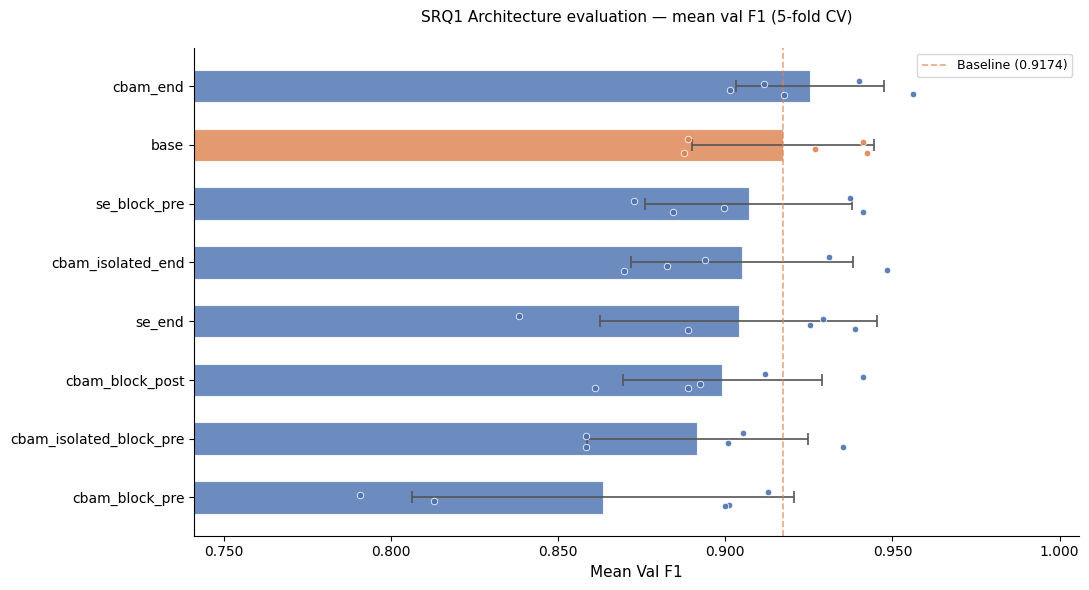

In [12]:
if len(df_ok) == 0:
    print("No completed runs yet — run Section 5 first.")
else:
    # Sort by mean F1 descending for the chart
    plot_df = summary.sort_values("mean_val_f1", ascending=True)  # ascending=True → highest at top

    fig, ax = plt.subplots(figsize=(11, 6))

    colours = ["#DD8452" if a == "base" else "#4C72B0" for a in plot_df["architecture"]]
    y_pos   = np.arange(len(plot_df))

    ax.barh(y_pos, plot_df["mean_val_f1"], xerr=plot_df["std_val_f1"],
            color=colours, alpha=0.82, height=0.55,
            capsize=4, error_kw=dict(elinewidth=1.2, ecolor="#555", capthick=1.2),
            edgecolor="white", linewidth=0.8)

    # Overlay individual fold values
    for i, arch in enumerate(plot_df["architecture"]):
        fold_f1 = df_ok.loc[df_ok["architecture"] == arch, "val_f1"].values
        jitter  = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(fold_f1))
        ax.scatter(fold_f1, i + jitter,
                   color="#DD8452" if arch == "base" else "#4C72B0",
                   edgecolors="white", linewidths=0.6, s=22, zorder=3, alpha=0.9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_df["architecture"], fontsize=10)
    ax.set_xlabel("Mean Val F1", fontsize=11)
    ax.set_title(
        f"SRQ1 Architecture evaluation — mean val F1 (5-fold CV)\n",
        fontsize=11
    )
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.spines[["top", "right"]].set_visible(False)

    # Zoom x-axis to meaningful range
    all_f1 = df_ok["val_f1"].values
    pad = (all_f1.max() - all_f1.min()) * 0.3 or 0.02
    ax.set_xlim(all_f1.min() - pad, all_f1.max() + pad)

    # Baseline reference line
    if "base" in summary["architecture"].values:
        base_f1 = summary.loc[summary["architecture"] == "base", "mean_val_f1"].values[0]
        ax.axvline(base_f1, color="#DD8452", linestyle="--", linewidth=1.2,
                   alpha=0.7, label=f"Baseline ({base_f1:.4f})")
        ax.legend(fontsize=9)

    plt.tight_layout()
    utils.save_fig(fig, PLOTS_DIR, "arch_eval_cv_f1", formats=("svg",))
    
    plt.show()

## 8 · Final Test Set Evaluation — SRQ1

Loads the best val F1 fold weights for each architecture and evaluates once on the held-out test set. Run once only after all CV decisions are made.

In [13]:
# ── Auto fold selection — best val F1 per architecture ──────────────────────
SELECTED_FOLDS = {}
for arch in ARCHITECTURES:
    arch_rows = df_ok[df_ok["architecture"] == arch].sort_values("val_f1", ascending=False)
    if arch_rows.empty:
        print(f"  WARNING: no completed folds for {arch}")
        continue
    SELECTED_FOLDS[arch] = int(arch_rows.iloc[0]["fold"])

print("Fold selection (best val F1 per architecture):")
print(f"  {'Architecture':<28} {'Fold':>5} {'val_f1':>8} {'val_loss':>10}")
print(f"  {'-'*55}")
for arch, fold in SELECTED_FOLDS.items():
    row = df_ok[(df_ok["architecture"] == arch) & (df_ok["fold"] == fold)]
    if not row.empty:
        r = row.iloc[0]
        print(f"  {arch:<28} {fold+1:>5} {r.val_f1:>8.4f} {r.val_loss:>10.4f}")


Fold selection (best val F1 per architecture):
  Architecture                  Fold   val_f1   val_loss
  -------------------------------------------------------
  base                             3   0.9423     0.1451
  cbam_end                         3   0.9561     0.1250
  cbam_block_pre                   5   0.9128     0.2301
  cbam_block_post                  1   0.9412     0.1748
  se_end                           3   0.9388     0.1605
  se_block_pre                     3   0.9412     0.1518
  cbam_isolated_end                3   0.9484     0.1729
  cbam_isolated_block_pre          3   0.9353     0.1650


In [14]:
# ── Test loader ───────────────────────────────────────────────────────────────
test_loader = data.get_test_loader(X_test, y_test, test_transform, batch_size=BATCH_SIZE)
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

get_test_loader()>>> Test loader ready — 331 samples
Device: cpu


In [15]:
# ── Evaluate all architectures on held-out test set ───────────────────────────
test_rows = []

for arch in ARCHITECTURES:
    fold_idx = SELECTED_FOLDS[arch]
    wpath    = utils.weights_path_for(WEIGHTS_DIR, arch, fold_idx)

    print(f"\n{'='*60}")
    print(f"  {arch}  (fold {fold_idx+1})")
    print(f"{'='*60}")

    if not wpath.exists():
        print(f"  SKIP — weights not found at {wpath}")
        continue

    utils.set_seed(SEED)
    model = models.get_model(architecture=arch, head=WINNING_HEAD)
    model = utils.load_weights(model, wpath, device=device)

    acc, prec, rec, f1, auc, ece, conf, report = evaluator.evaluate_model(
        model=model, test_loader=test_loader, device=device
    )

    test_rows.append({
        "architecture"    : arch,
        "selected_fold"   : fold_idx,
        "test_f1"         : round(f1,   4),
        "test_auc"        : round(auc,  4),
        "test_ece"        : round(ece,  4),
        "test_acc"        : round(acc,  4),
        "test_prec"       : round(prec, 4),
        "test_rec"        : round(rec,  4),
        "conf_matrix"     : conf.tolist(),
    })

df_test = pd.DataFrame(test_rows).set_index("architecture")
df_test = df_test.reindex([a for a in ARCHITECTURES if a in df_test.index])


  base  (fold 3)
Random seed set to 42 for Python, NumPy, and PyTorch
get_model()>>> architecture='base'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
Accuracy  : 0.9335
Precision : 0.9219
Recall    : 0.9077
F1        : 0.9147
AUC-ROC   : 0.9855
ECE       : 0.0463  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[191  10]
 [ 12 118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       201
           1       0.92      0.91      0.91       130

    accuracy                           0.93       331
   macro avg       0.93      0.93      0.93       331
weighted avg       0.93      0.93      0.93       331


  cbam_end  (fold 3)
Random seed set to 42 for Python, NumPy, and PyTorch
get_model()>>> architecture='cbam_end'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
Accuracy  : 0.9275
Precision : 0.9344
Recall    : 0.8769


In [16]:
# ── Results table ─────────────────────────────────────────────────────────────
baseline_f1 = df_test.loc["base", "test_f1"] if "base" in df_test.index else None

print("SRQ1 — Final Test Results\n")
print(f"{'Architecture':<28} {'F1':>7} {'AUC':>7} {'ECE':>7} {'Acc':>7}  ΔF1")
print("-" * 65)
for arch, row in df_test.iterrows():
    delta = f"{row.test_f1 - baseline_f1:+.4f}" if baseline_f1 and arch != "base" else "baseline"
    print(f"  {arch:<26} {row.test_f1:>7.4f} {row.test_auc:>7.4f} "
          f"{row.test_ece:>7.4f} {row.test_acc:>7.4f}  {delta}")

# ── SRQ1 comparison pairs ─────────────────────────────────────────────────────
print("\nSRQ1 Comparison Pairs:\n")
pairs = [
    ("Pair A", "base",              "se_end",             "Does channel attention help?"),
    ("Pair B", "se_end",            "cbam_isolated_end",  "Does spatial attention add value?"),
    ("Pair C", "cbam_isolated_end", "cbam_end",           "Does dual-pool channel beat single-pool?"),
    ("Pair D", "se_end",            "cbam_end",           "SE vs CBAM overall?"),
]
for label, a, b, question in pairs:
    if a not in df_test.index or b not in df_test.index:
        continue
    f1_a, f1_b = df_test.loc[a, "test_f1"], df_test.loc[b, "test_f1"]
    winner = b if f1_b > f1_a else a if f1_a > f1_b else "tie"
    print(f"  {label}: {a} ({f1_a:.4f}) vs {b} ({f1_b:.4f})  Δ={f1_b-f1_a:+.4f}  → {winner}")
    print(f"         {question}\n")

SRQ1 — Final Test Results

Architecture                      F1     AUC     ECE     Acc  ΔF1
-----------------------------------------------------------------
  base                        0.9147  0.9855  0.0463  0.9335  baseline
  cbam_end                    0.9048  0.9845  0.0421  0.9275  -0.0099
  cbam_block_pre              0.8945  0.9793  0.0657  0.9245  -0.0202
  cbam_block_post             0.9407  0.9883  0.0369  0.9547  +0.0260
  se_end                      0.9143  0.9792  0.0418  0.9366  -0.0004
  se_block_pre                0.9113  0.9831  0.0558  0.9335  -0.0034
  cbam_isolated_end           0.9294  0.9871  0.0431  0.9426  +0.0147
  cbam_isolated_block_pre     0.8934  0.9711  0.0546  0.9215  -0.0213

SRQ1 Comparison Pairs:

  Pair A: base (0.9147) vs se_end (0.9143)  Δ=-0.0004  → base
         Does channel attention help?

  Pair B: se_end (0.9143) vs cbam_isolated_end (0.9294)  Δ=+0.0151  → cbam_isolated_end
         Does spatial attention add value?

  Pair C: cbam_isolate

In [17]:
# ── Save test results ─────────────────────────────────────────────────────────
TEST_RESULTS_FILE = RESULTS_DIR / "arch_eval_test_results.csv"
df_test.drop(columns=["conf_matrix"]).to_csv(TEST_RESULTS_FILE)
print(f"Test results saved → {TEST_RESULTS_FILE}")

Test results saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\arch_eval_test_results.csv


save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results\plots\srq1_test_results.svg


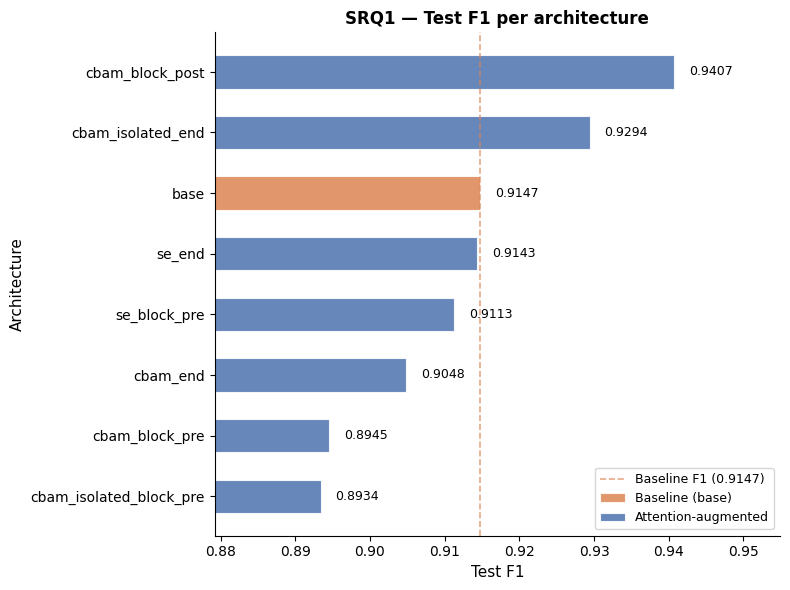

In [ ]:
# ── Visualisation ─────────────────────────────────────────────────────────────
if not df_test.empty:
    plot_order  = df_test.sort_values("test_f1", ascending=True)
    y_pos       = np.arange(len(plot_order))
    is_baseline = np.array([a == "base" for a in plot_order.index])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(y_pos[ is_baseline], plot_order["test_f1"][ is_baseline],
            color="#DD8452", alpha=0.85, height=0.55, edgecolor="white",
            linewidth=0.8, label="Baseline (base)")
    ax.barh(y_pos[~is_baseline], plot_order["test_f1"][~is_baseline],
            color="#4C72B0", alpha=0.85, height=0.55, edgecolor="white",
            linewidth=0.8, label="Attention-augmented")
    if baseline_f1:
        ax.axvline(baseline_f1, color="#DD8452", linestyle="--",
                   linewidth=1.2, alpha=0.7, label=f"Baseline F1 ({baseline_f1:.4f})")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_order.index, fontsize=10)
    ax.set_xlabel("Test F1", fontsize=11)
    ax.set_ylabel("Architecture", fontsize=11)
    ax.set_title("SRQ1 — Test Set F1 per architecture", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    f1_vals = plot_order["test_f1"].values
    pad = (f1_vals.max() - f1_vals.min()) * 0.3 or 0.02
    ax.set_xlim(max(0, f1_vals.min() - pad), min(1, f1_vals.max() + pad))
    for y, v in zip(y_pos, f1_vals):
        ax.text(v + 0.002, y, f"{v:.4f}", va="center", fontsize=9)

    plt.tight_layout()
    utils.save_fig(fig, PLOTS_DIR, "srq1_test_results", formats=("svg",))
    plt.show()